# Datalab 2
In this datalab, we focus on working with probability distribution-related functions in Python. This is central for many of the things we will do in later modules. We divide the datalab into sections related to the distributions we consider. We will use examples of what types of situations these distributions may occur in from the real world. The goal of this data lab is mostly that you get more familiar with the functions related to the various distributions. We will start with Bernoulli, before considering the Binomial and Normal distributions. 

## Bernoulli distribution
A company is advertising on a website. Each customer independently clicks on the ad with probability 0.15. We consider the event "Customer clicks the ad", which is a binary. Either the customer clicks ($X=1$) or does not ($X=0$). This is a Bernoulli-distributed variable with a probability of success $p=0.15$. Let us graph the probability distribution for this discrete variable. 

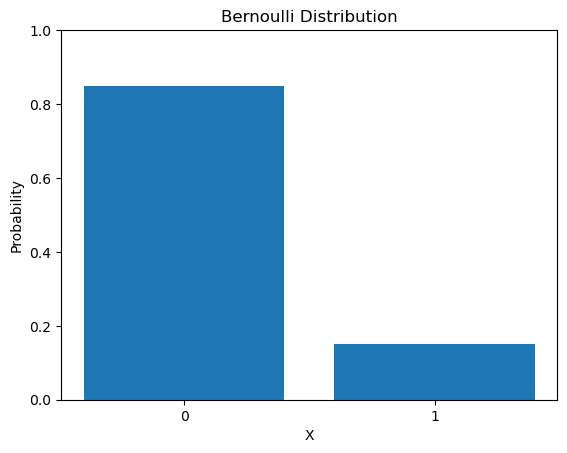

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# Bernoulli parameter
p = 0.15

# Possible outcomes
x = np.array([0, 1])

# Probability mass function
pmf = bernoulli.pmf(x, p)

# Plot
plt.bar(x, pmf)
plt.xticks([0, 1])
plt.xlabel("X")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution")
plt.ylim(0, 1)

plt.show()

For a random customer that enters the website, the probabilty is 0.96 that they will not click the add and 0.04 that they will. 

## Binomial distribution
If we instead consider 10 customers entering the website, the number of clicks follows a binomial distribution. The random variable is then the number of customers (out of the 10) that clicked the ad. We know that the expected value of a binomial distributed variables is $n\cdot p$, where $n$ is the customers and $p$ is the probability that the customer clicks the ad. In this case, we get $np=10\cdot 0.15=1.5$. On average, we therefore expect 1.5 of the 10 customers to click the ad. Let us plot the distribution and cumulative distribution function for this distribution.

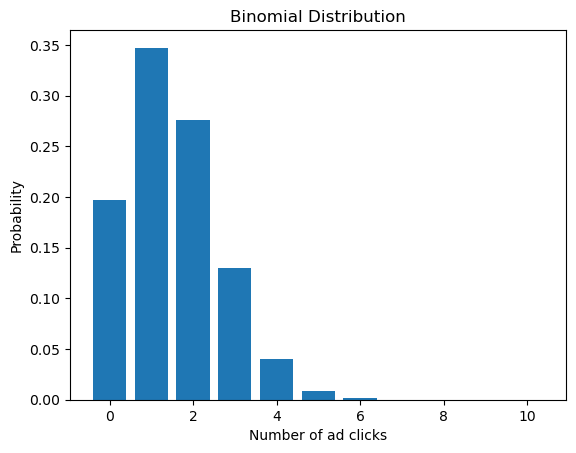

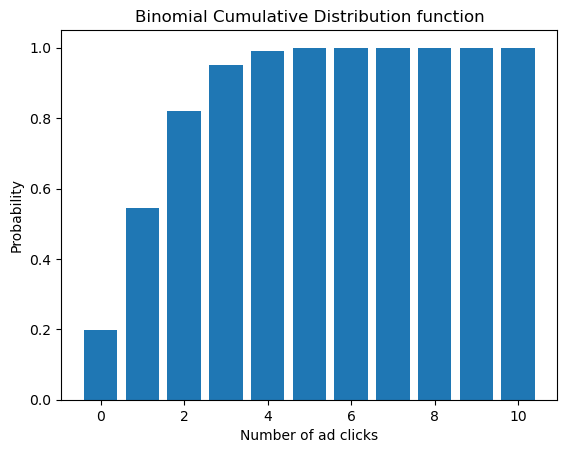

In [3]:
from scipy.stats import binom

# Binomial parameters
n = 10
p = 0.15

# Possible outcomes: number of successes
x = np.arange(0, n + 1)

# Probability mass function
pmf = binom.pmf(x, n, p)
# Cumulative distribution function
cdf = binom.cdf(x,n,p)
# Plot
plt.bar(x, pmf)
plt.xlabel("Number of ad clicks")
plt.ylabel("Probability")
plt.title("Binomial Distribution")
plt.show()
plt.bar(x, cdf)
plt.xlabel("Number of ad clicks")
plt.ylabel("Probability")
plt.title("Binomial Cumulative Distribution function")
plt.show()

### Task
Use the plots above to answer the following:

1. What is the probability that exactly one customer clicks the ad?
2. What is the probability that less than three customers click the ad? 
3. What is the probability that more than two customers click the ad? 
4. What is the probability that someone click the ad?

Do the same task using the functions binom.pmf and binom.cdf?

### Solution:
1. We can read from the first figure that the probability of exactly one customer clicking is 0.35.
2. The probability that fewer than three customers click can be read from the second graph for $P(X<3)=P(X\le 2)=F(2)\approx 0.8$.
3. $P(X>2) =1-P(X\le 2)=1-F(2)=1-0.8=0.2$.
4. From the first graph, we have that $P(X=0)=0.2$. $P(\text{"someone clicks"}) = 1-P(\text{"nobody clicks"}) =1-P(X=0)=1-0.2=0.8$

In [4]:
print("1: ", binom.pmf(1,   n, p))
print("2: ", binom.cdf(2,   n, p))
print("3: ", 1-binom.cdf(2, n, p))
print("4: ", 1-binom.cdf(0, n, p))

1:  0.3474254194248047
2:  0.8201964803675781
3:  0.17980351963242192
4:  0.8031255956592773


Test out what happens if you increase/decrease the "probability of success" parameter $p$ to 0.8 or 0.05. What happens if we can attract more customers to the website?

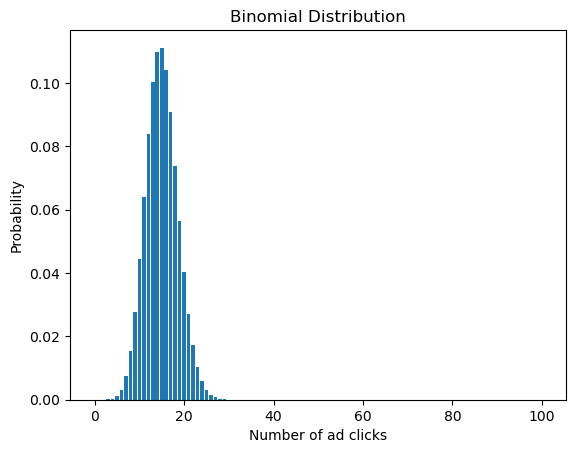

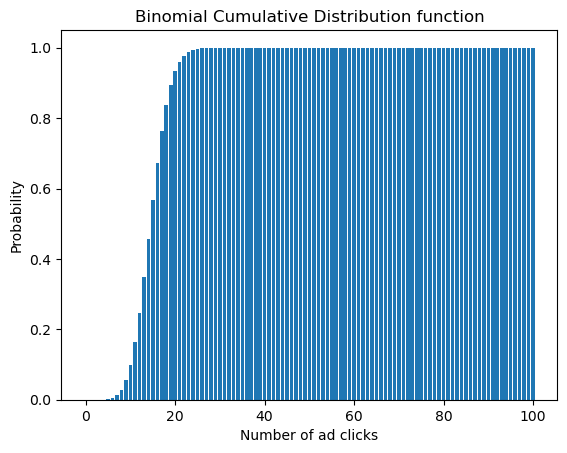

In [5]:
# Solution: 
# Binomial parameters
n = 100 #10
p = 0.15 # 0.05


# Possible outcomes: number of successes
x = np.arange(0, n + 1)

# Probability mass function
pmf = binom.pmf(x, n, p)
# Cumulative distribution function
cdf = binom.cdf(x,n,p)

# Plot
plt.bar(x, pmf)
plt.xlabel("Number of ad clicks")
plt.ylabel("Probability")
plt.title("Binomial Distribution")
plt.show()
plt.bar(x, cdf)
plt.xlabel("Number of ad clicks")
plt.ylabel("Probability")
plt.title("Binomial Cumulative Distribution function")
plt.show()

### Solution
If we increase the probability of success, the probability mass is shifted to the right - increaseing the expected number of clicks on the ad. If we decrease it, it becomes more likely with fewer customers clicking. Increasing the sample size increases the expected value, but the proportion of customers clicking is the same. This shows that there are two ways to increase the expected number of clicks. We can either make the ad more tempting to click on (increase $p$) or increase the exposure to the ad (increasing sample size $n$). This is also clear from the formula $E(X)=np$.

## Normal distribution
Let us now consider the normal distribution. This is a continuous distribution, defined by the two parameters $\mu$ and $\sigma$, where $\mu$ is the expectation and $\sigma$ is the standard deviation. Let us assume that $X$ is the return on a stock, and we assume that the return of the stock tomorrow is normally distributed with expectation 0 and variance 1. This is called a **standard normal distribution**. Let us plot the (probability) density function (pdf), the cumulative distribution function (cdf), and the quantile (percentage point) function (ppf).

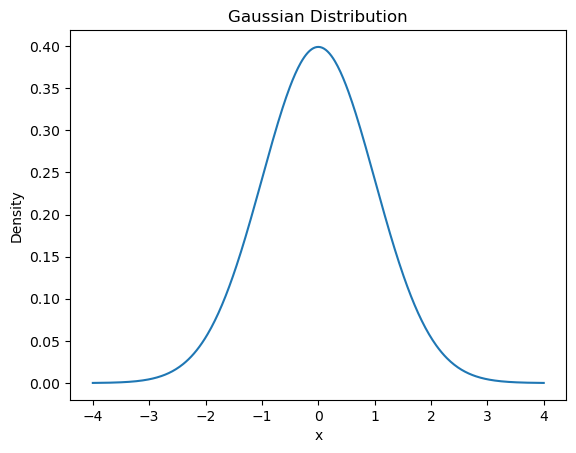

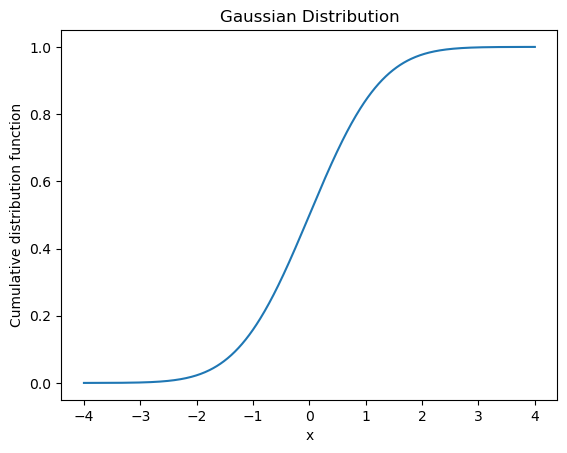

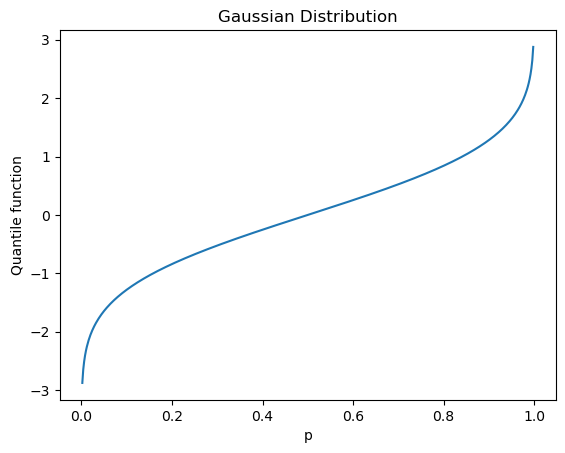

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Gaussian parameters
mu = 0
sigma = 1

# Range of values
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
p =  np.linspace(0,1, 500)

# Probability density function
pdf = norm.pdf(x, mu, sigma)
# Cumulative distribution function
cdf = norm.cdf(x,mu,sigma)
# Quantile function
ppf = norm.ppf(p,mu,sigma)

# Plot
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian Distribution")
plt.show()
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("Cumulative distribution function")
plt.title("Gaussian Distribution")
plt.show()
plt.plot(p, ppf)
plt.xlabel("p")
plt.ylabel("Quantile function")
plt.title("Gaussian Distribution")
plt.show()



# Task
1. What is the probability that $X=0$?
2. What is the density in $x=0$?
3. What is the probability that $X\le-1$?
4. What is the probability that $-1\le X\le 1$?
5. What is the value x that fulfills $P(X\le x) = 0.5$?
6. What is the value x that fulfills $P(X\le x) = 0.975$?

Use the plots first and then use the functions norm.pdf,  norm.cdf and norm.ppf.

### Solution
1. **This is a trick question!!!** The probability that a continuous random variable is exactly equal to any number is zero. To consider probabilities, we need intervals (not points). 
2. The density at x=0 is around 0.4 (from the density plot).
3. $P(X\le -1) \approx 0.2$ from the cdf plot.
4. $P(-1\le X\le1) = P(X\le 1)-P(X\le -1) \approx 0.8 - 0.2 =0.6$ (from the cdf plot). The more exact value is 0.68. This means that 68\% of the probability mass of a normal distribution is contained in the interval $[\mu-\sigma,\mu+\sigma]$ (illustrated for $\mu=0$ and $\sigma = 1$ here).
5. Here we can use the ppf and evaluate it at $p=0.5$, giving x=0. This means that $0$ is the median of the normal distribution (same as the mean). This is a characteristic of symmetric distributions.
6. Here we can use the ppf and evaluate it at $p=0.975$, giving roughly x=2 (exact value: 1.96). This can be hard to see from the plot. This tells us that the probability is around 97.5\% that X will be smaller than $\mu+2\, \sigma$ (here $\mu=0$ and $\sigma=1$, but this is a general result for the normal distribution). 

In [7]:
# Exact solutions: 
print("2: ", norm.pdf(0,  mu, sigma))
print("3: ", norm.cdf(-1,  mu, sigma))
print("4: ", norm.cdf(1,  mu, sigma)-norm.cdf(-1,  mu, sigma))
print("5: ", norm.ppf(0.5,  mu, sigma))
print("6: ", norm.ppf(0.975,  mu, sigma))

2:  0.3989422804014327
3:  0.15865525393145707
4:  0.6826894921370859
5:  0.0
6:  1.959963984540054
